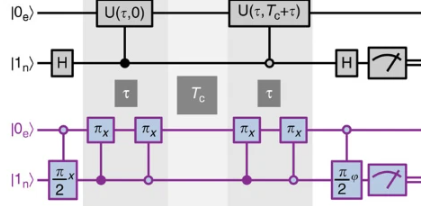

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits)

# Step 2: Prepare the initial state |0> for qubit 0 and |1> for qubit 1
# Here, we're preparing the state |0> (electron) and |1> (nitrogen)
qc.initialize([1, 0], 0)  # Initialize qubit 0 (electron) to |0>
qc.initialize([0, 1], 1)  # Initialize qubit 1 (nitrogen) to |1>

# Step 3: Apply controlled rotation gates
# Controlled rotation π/2 around X-axis with nitrogen as controller
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Controlled rotation π around X-axis with electron as controller
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)

# Step 4: Repeat the operations (as in the original logic)
qc.crx(np.pi , 1, 0)  # Control qubit: nitrogen (1), target qubit: electron (0)
qc.crx(np.pi, 1, 0)      # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)  
# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 6: Measure the qubits
qc.measure_all()

# Step 7: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 8: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 9: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 10: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 11: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 12: Optionally, visualize the results
plot_histogram(counts)

# Step 13: Draw the circuit (optional)
print(qc.draw('mpl'))


Total counts: {'10': 1024}
Figure(998.442x284.278)


In [2]:
%matplotlib inline

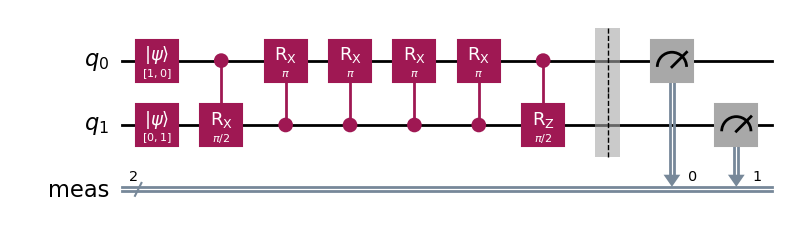

In [3]:
qc.draw('mpl')

Circuit after initialization:
Figure(454.517x284.278)
Circuit after first controlled rotation:
Figure(956.183x284.278)
Circuit after second controlled rotation:
Figure(1708.68x284.278)
Final circuit before measurement:
Figure(2210.35x618.722)
Total counts: {'11': 1024}


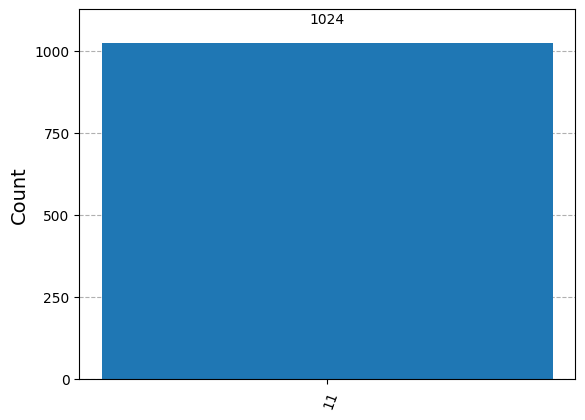

In [4]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits, n_qubits)  # Added classical bits for measurement

# Step 2: Prepare the initial state |0> for qubit 0 and |1> for qubit 1
qc.initialize([1, 0], 0)  # Initialize qubit 0 (electron) to |0>
qc.initialize([0, 1], 1)  # Initialize qubit 1 (nitrogen) to |1>

# Intermediate Check 1: Measure after initialization
qc.barrier()
qc.measure([0, 1], [0, 1])
print("Circuit after initialization:")
print(qc.draw('mpl'))

# Reset the circuit for further operations (after measuring)
qc.reset([0, 1])
qc.initialize([1, 0], 0)
qc.initialize([0, 1], 1)

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Intermediate Check 2: Measure after the first controlled rotation
qc.barrier()
qc.measure([0, 1], [0, 1])
print("Circuit after first controlled rotation:")
print(qc.draw('mpl'))

# Reset the circuit for further operations (after measuring)
qc.reset([0, 1])
qc.initialize([1, 0], 0)
qc.initialize([0, 1], 1)
qc.crx(np.pi / 2, 0, 1)

# Step 4: Repeat the operations
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)

# Intermediate Check 3: Measure after the second controlled rotation
qc.barrier()
qc.measure([0, 1], [0, 1])
print("Circuit after second controlled rotation:")
print(qc.draw('mpl'))

# Reset the circuit for further operations (after measuring)
qc.reset([0, 1])
qc.initialize([1, 0], 0)
qc.initialize([0, 1], 1)
qc.crx(np.pi / 2, 0, 1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Intermediate Check 4: Final state before measurement
qc.barrier()
qc.measure([0, 1], [0, 1])
print("Final circuit before measurement:")
print(qc.draw('mpl'))

# Step 6: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 7: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 8: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 9: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 10: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 11: Optionally, visualize the results
plot_histogram(counts)


In [5]:
%matplotlib inline

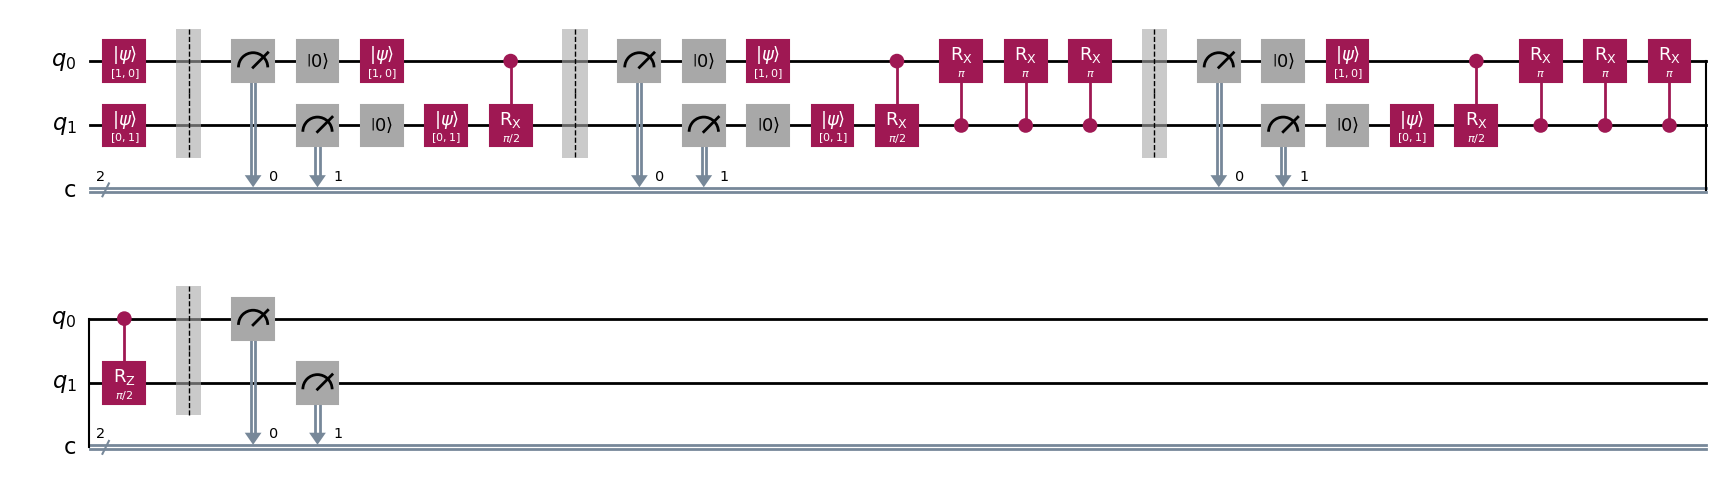

In [6]:
qc.draw('mpl')

In [8]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits, n_qubits)  # Added classical bits for measurement

# Step 2: Prepare the initial state |0> for qubit 0 and |1> for qubit 1
qc.initialize([1, 0], 0)  # Initialize qubit 0 (electron) to |0>
qc.initialize([0, 1], 1)  # Initialize qubit 1 (nitrogen) to |1>

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 4: Repeat the operations
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 6: Measure the qubits at the end
qc.measure([0, 1], [0, 1])  # Measure qubit 0 and qubit 1

# Step 7: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 8: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 9: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 10: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 11: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 12: Optionally, visualize the results
plot_histogram(counts)

# Step 13: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'10': 1024}
Figure(872.572x284.278)


In [9]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits, n_qubits)  # Added classical bits for measurement

# Step 2: Prepare the initial state |0> for qubit 0 (electron)
qc.initialize([1, 0], 0)  # Initialize qubit 0 to |0>

# Prepare the superposition state (|0> + |1>) for qubit 1 (nitrogen)
qc.h(1)  # Apply Hadamard gate to qubit 1

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 4: Repeat the operations
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 6: Measure the qubits at the end
qc.measure([0, 1], [0, 1])  # Measure qubit 0 and qubit 1

# Step 7: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 8: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 9: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 10: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 11: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 12: Optionally, visualize the results
plot_histogram(counts)

# Step 13: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'00': 526, '10': 498}
Figure(872.572x284.278)


In [10]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits, n_qubits)  # Added classical bits for measurement

# Step 2: Prepare the initial state |0> for qubit 0 (electron)
qc.initialize([1, 0], 0)  # Initialize qubit 0 to |0>

# Prepare the superposition state (|0> + |1>) for qubit 1 (nitrogen)
qc.h(1)  # Apply Hadamard gate to qubit 1

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 4: Repeat the operations
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 6: Apply Hadamard gate to nitrogen before measurement
qc.h(1)

# Step 7: Measure the qubits at the end
qc.measure([0, 1], [0, 1])  # Measure qubit 0 and qubit 1

# Step 8: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 9: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 10: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 11: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 12: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 13: Optionally, visualize the results
plot_histogram(counts)

# Step 14: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'00': 1024}
Figure(956.183x284.278)


In [11]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for the measurement of qubit 1 (nitrogen)

# Step 2: Prepare the initial state |0> for qubit 0 (electron)
qc.initialize([1, 0], 0)  # Initialize qubit 0 to |0>

# Prepare the superposition state (|0> + |1>) for qubit 1 (nitrogen)
qc.h(1)  # Apply Hadamard gate to qubit 1

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 4: Repeat the operations
qc.crx(np.pi, 1, 0)  # Control qubit: electron (0), target qubit: nitrogen (1)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)
qc.crx(np.pi, 1, 0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Control qubit: nitrogen (1), target qubit: electron (0)

# Step 6: Apply Hadamard gate to nitrogen before measurement
qc.h(1)

# Step 7: Measure only the nitrogen qubit (qubit 1)
qc.measure(1, 0)  # Measure qubit 1 (nitrogen) and store the result in classical bit 0

# Step 8: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 9: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 10: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 11: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 12: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 13: Optionally, visualize the results
plot_histogram(counts)

# Step 14: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'0': 1024}
Figure(872.572x284.278)


In [12]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit and Nitrogen qubit
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for measurement of Nitrogen qubit

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Create the entangled state |00> + |11>
qc.cx(1, 0)  # CNOT: Control qubit is nitrogen (1), target qubit is electron (0)

# Step 4: Apply phase accumulation (Rz gate simulates phase accumulation)
phi_1 = np.pi / 4  # Example phase accumulation
qc.rz(phi_1, 1)  # Apply Rz on nitrogen qubit to accumulate phase

# Step 5: Disentangle qubits
qc.cx(1, 0)  # CNOT to disentangle qubits

# Step 6: Simulate correlation time Tc and detuning phase
delta_phi = np.pi / 8  # Example detuning phase
qc.rz(delta_phi, 1)  # Apply additional Rz on nitrogen qubit

# Step 7: Final CnROTe gate pair (refocus magnetic fields)
qc.cx(1, 0)  # Apply CNOT gate again
qc.cx(0, 1)  # Apply CNOT gate with roles reversed

# Step 8: Measure the memory qubit (nitrogen)
qc.measure(1, 0)  # Measure nitrogen qubit and store result in classical bit 0

# Step 9: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 10: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 11: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 12: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 13: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 14: Optionally, visualize the results
plot_histogram(counts)

# Step 15: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'0': 1024}
Figure(788.961x284.278)


In [13]:
%matplotlib inline

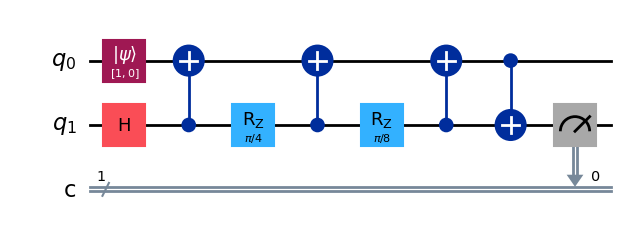

In [14]:
qc.draw('mpl')

In [19]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit (0) and Nitrogen qubit (1)
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for measurement of Nitrogen qubit

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 0, 1)  # Controlled RX on electron (0) controlled by nitrogen (1)

# Step 4: Repeat the operations
for _ in range(4):
    qc.crx(np.pi, 1, 0)  # Controlled RX on nitrogen (1) controlled by electron (0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Controlled RZ on electron (0) controlled by nitrogen (1)
qc.h(1)
# Step 6: Measure the nitrogen qubit (memory qubit)
qc.measure(1, 0)  # Measure nitrogen qubit and store result in classical bit 0

# Step 7: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 8: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 9: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 10: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 11: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 12: Optionally, visualize the results
plot_histogram(counts)

# Step 13: Draw the final circuit (optional)
print(qc.draw('mpl'))


Total counts: {'0': 1024}
Figure(872.572x284.278)


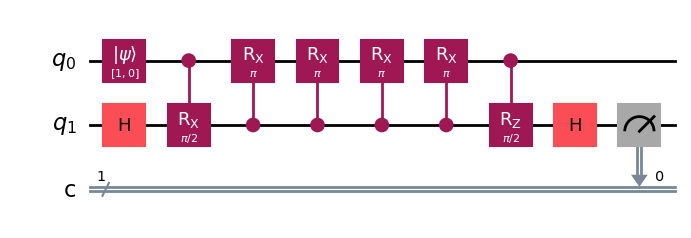

In [20]:
qc.draw('mpl')

In [24]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit (0) and Nitrogen qubit (1)
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for measurement of Nitrogen qubit

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Apply controlled rotation gates
qc.crx(np.pi / 2, 1, 0)  # Controlled RX on electron (0) controlled by nitrogen (1)

# Step 4: Repeat the operations
for _ in range(4):
    qc.crx(np.pi, 0, 1)  # Controlled RX on nitrogen (1) controlled by electron (0)

# Step 5: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 1, 0)  # Controlled RZ on electron (0) controlled by nitrogen (1)
qc.h(1) 
# Step 6: Measure the nitrogen qubit (memory qubit)
qc.measure(1, 0)  # Measure nitrogen qubit and store result in classical bit 0

# Step 7: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 8: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 9: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 10: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 11: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 12: Calculate and apply readout fidelity
readout_fidelity = 0.6 # Adjust this value based on your system's characteristics
fidelity_counts = {key: int(value * readout_fidelity) for key, value in counts.items()}

# Step 13: Optionally, visualize the results
plot_histogram(fidelity_counts)

# Step 14: Draw the final circuit (optional)
print(qc.draw('mpl'))

# Step 15: Discard results based on initialization
if '0' not in fidelity_counts:
    print("Memory not initialized, discarding readout.")
else:
    print("Memory initialized, readout valid.")


Total counts: {'1': 249, '0': 775}
Figure(872.572x284.278)
Memory initialized, readout valid.


In [25]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit (0) and Nitrogen qubit (1)
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for measurement of Nitrogen qubit

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Apply initial controlled rotation gates
qc.crx(np.pi / 2, 1, 0)  # Controlled RX on electron (0) controlled by nitrogen (1)

# Step 4: Free evolution time (simulated using identity gates or a delay if applicable)
qc.id(0)  # Placeholder for free evolution

 # Controlled RX on nitrogen (1) controlled by electron (0)
 qc.crx(np.pi, 1, 0) 
 qc.crx(np.pi, 1, 0) 
 qc.crx(np.pi, 1, 0) 
 qc.crx(np.pi, 1, 0) 
# Step 6: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 1, 0)  # Controlled RZ on electron (0) controlled by nitrogen (1)

# Step 7: Free evolution again before measurement
qc.id(0)  # Placeholder for free evolution

# Step 8: Measure the nitrogen qubit (memory qubit)
qc.measure(1, 0)  # Measure nitrogen qubit and store result in classical bit 0

# Step 9: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 10: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 11: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 12: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 13: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 14: Calculate and apply readout fidelity
readout_fidelity = 0.6  # Adjust this value based on your system's characteristics
fidelity_counts = {key: int(value * readout_fidelity) for key, value in counts.items()}

# Step 15: Optionally, visualize the results
plot_histogram(fidelity_counts)

# Step 16: Draw the final circuit (optional)
print(qc.draw('mpl'))

# Step 17: Discard results based on initialization
if '0' not in fidelity_counts:
    print("Memory not initialized, discarding readout.")
else:
    print("Memory initialized, readout valid.")


Total counts: {'1': 515, '0': 509}
Figure(872.572x284.278)
Memory initialized, readout valid.


In [38]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Define parameters
t = 0.5  # Free evolution time in arbitrary units
Tc = 0.3  # Correlation time in arbitrary units
ge = 2.0  # Gyromagnetic ratio (for example)
Bz = 1.0  # Magnetic field strength (arbitrary units)

# Calculate phase shifts for free evolution
f1 = ge * Bz * t  # Phase shift due to free evolution time t
f2 = ge * Bz * Tc  # Phase shift during correlation time Tc
f3 = ge * Bz * t  # Phase shift due to second free evolution time t

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit (0) and Nitrogen qubit (1)
qc = QuantumCircuit(n_qubits, 1)  # 1 classical bit for measurement of Nitrogen qubit

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Apply initial controlled rotation gate
qc.crx(np.pi / 2, 0, 1)  # Controlled RX on electron (0) controlled by nitrogen (1)

# Step 4: Free evolution with phase shift due to time t
qc.crx(np.pi , 1, 0)
# Step 6: Free evolution with phase shift during correlation time Tc
qc.rz(f1, 0)  # Apply phase shift for correlation time
qc.crx(np.pi, 1, 0) 
qc.rz(f2, 0)
# Step 5: Controlled RX on nitrogen (1) controlled by electron (0)
qc.crx(np.pi, 1, 0) 
qc.rz(f2, 0)
qc.crx(np.pi, 1, 0)  # Repeated controlled RX as per your original code


# Step 7: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Controlled RZ on electron (0) controlled by nitrogen (1)


# Step 9: Measure the nitrogen qubit (memory qubit)
qc.measure(1, 0)  # Measure nitrogen qubit and store result in classical bit 0

# Step 10: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 11: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 12: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 13: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 14: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 15: Calculate and apply readout fidelity
readout_fidelity = 0.6  # Adjust this value based on your system's characteristics
fidelity_counts = {key: int(value * readout_fidelity) for key, value in counts.items()}

# Step 16: Optionally, visualize the results
plot_histogram(fidelity_counts)

# Step 17: Draw the final circuit (optional)
print(qc.draw('mpl'))

# Step 18: Discard results based on initialization
if '0' not in fidelity_counts:
    print("Memory not initialized, discarding readout.")
else:
    print("Memory initialized, readout valid.")


Total counts: {'1': 507, '0': 517}
Figure(1039.79x284.278)
Memory initialized, readout valid.


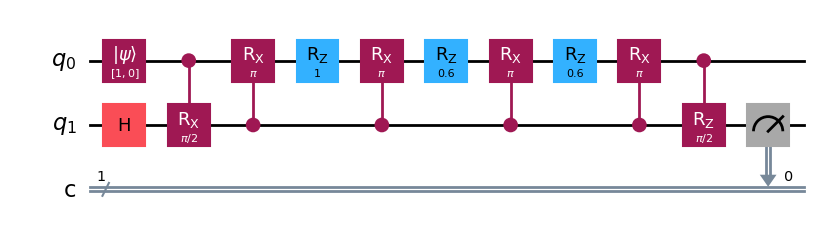

In [39]:
qc.draw('mpl')

In [40]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Define parameters
t = 0.5  # Free evolution time in arbitrary units
Tc = 0.3  # Correlation time in arbitrary units
ge = 2.0  # Gyromagnetic ratio (for example)
Bz = 1.0  # Magnetic field strength (arbitrary units)

# Calculate phase shifts for free evolution
f1 = ge * Bz * t  # Phase shift due to free evolution time t
f2 = ge * Bz * Tc  # Phase shift during correlation time Tc
f3 = ge * Bz * t  # Phase shift due to second free evolution time t

# Step 1: Initialize the Quantum Circuit
n_qubits = 2  # Electron qubit (0) and Nitrogen qubit (1)
qc = QuantumCircuit(n_qubits, 2)  # 2 classical bits for measurement

# Step 2: Prepare the initial state |0> for electron and superposition for nitrogen
qc.initialize([1, 0], 0)  # Electron qubit |0>
qc.h(1)  # Nitrogen qubit in superposition (|0> + |1>)

# Step 3: Apply initial controlled rotation gate
qc.crx(np.pi / 2, 0, 1)  # Controlled RX on electron (0) controlled by nitrogen (1)

# Step 4: Free evolution with phase shift due to time t
qc.crx(np.pi , 1, 0)
# Step 6: Free evolution with phase shift during correlation time Tc
qc.rz(f1, 0)  # Apply phase shift for correlation time
qc.crx(np.pi, 1, 0) 
qc.rz(f2, 0)
# Step 5: Controlled RX on nitrogen (1) controlled by electron (0)
qc.crx(np.pi, 1, 0) 
qc.rz(f2, 0)
qc.crx(np.pi, 1, 0)  # Repeated controlled RX as per your original code

# Apply Hadamard to the electron qubit to retrieve the phase
qc.h(0)

# Step 7: Controlled operation π/2 on nitrogen as controller
qc.crz(np.pi / 2, 0, 1)  # Controlled RZ on electron (0) controlled by nitrogen (1)

# Step 9: Measure both qubits
qc.measure(0, 0)  # Measure electron qubit and store result in classical bit 0
qc.measure(1, 1)  # Measure nitrogen qubit and store result in classical bit 1

# Step 10: Use Aer's qasm_simulator
backend = Aer.get_backend('qasm_simulator')

# Step 11: Transpile the circuit for the backend
transpiled_circuit = transpile(qc, backend)

# Step 12: Execute the circuit on the qasm simulator
job = backend.run(transpiled_circuit, shots=1024)  # Create a job

# Step 13: Wait for the job to complete and get the result
result = job.result()  # Retrieve the results

# Step 14: Get the counts and print the results
counts = result.get_counts(transpiled_circuit)  # Get the count data
print("Total counts:", counts)

# Step 15: Calculate and apply readout fidelity
readout_fidelity = 0.6  # Adjust this value based on your system's characteristics
fidelity_counts = {key: int(value * readout_fidelity) for key, value in counts.items()}

# Step 16: Optionally, visualize the results
plot_histogram(fidelity_counts)

# Step 17: Draw the final circuit (optional)
print(qc.draw('mpl'))

# Step 18: Discard results based on initialization
if '0' not in fidelity_counts:
    print("Memory not initialized, discarding readout.")
else:
    print("Memory initialized, readout valid.")


Total counts: {'01': 230, '00': 253, '11': 282, '10': 259}
Figure(1207.02x284.278)
Memory not initialized, discarding readout.


In [41]:
# Step 18: Check if any valid outcomes are present and interpret them
if any(key in fidelity_counts for key in ['00', '01', '10', '11']):
    print("Memory initialized, readout valid.")
else:
    print("Memory not initialized, discarding readout.")


Memory initialized, readout valid.


In [42]:
# Calculate total shots (sum of all counts)
total_shots = sum(fidelity_counts.values())

# Convert counts to probabilities
probabilities = {key: value / total_shots for key, value in fidelity_counts.items()}
print("Probabilities:", probabilities)


Probabilities: {'01': 0.22512234910277323, '00': 0.2463295269168026, '11': 0.27569331158238175, '10': 0.2528548123980424}


In [43]:
import numpy as np

# Assume P00 corresponds to the probability of measuring '00'
P00 = probabilities.get('00', 0)

# Estimate phase φ
phi_estimate = 2 * np.arccos(np.sqrt(P00))
print("Estimated phase (radians):", phi_estimate)
print("Estimated phase (degrees):", np.degrees(phi_estimate))


Estimated phase (radians): 2.102892643737743
Estimated phase (degrees): 120.48687325528049


In [45]:
P1 = probabilities['01'] + probabilities['11']
